In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dt = pd.read_csv('/kaggle/input/datasets/mragpavank/insurance1/insurance.csv')
dt.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# What does the data look like?

In [3]:
dt.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [4]:
dt.shape

(1338, 7)

## Basic statistic

In [5]:
dt.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Do smokers pay higher insurance?

In [6]:
dt[dt['smoker'] == 'yes']
smokedata = dt[dt['smoker'] == 'yes'].drop(['sex','children','region', 'bmi'], axis = 1)
smokedata

,age,smoker,charges
0,19,yes,16884.92400
11,62,yes,27808.72510
14,27,yes,39611.75770
19,30,yes,36837.46700
23,34,yes,37701.87680
...,...,...,...
1313,19,yes,36397.57600
1314,30,yes,18765.87545
1321,62,yes,28101.33305
1323,42,yes,43896.37630


In [7]:
smokedata.describe()

,age,charges
count,274.000000,274.000000
mean,38.514599,32050.231832
std,13.923186,11541.547176
min,18.000000,12829.455100
25%,27.000000,20826.244213
50%,38.000000,34456.348450
75%,49.000000,41019.207275
max,64.000000,63770.428010


Text(0, 0.5, 'Insurance Charges')

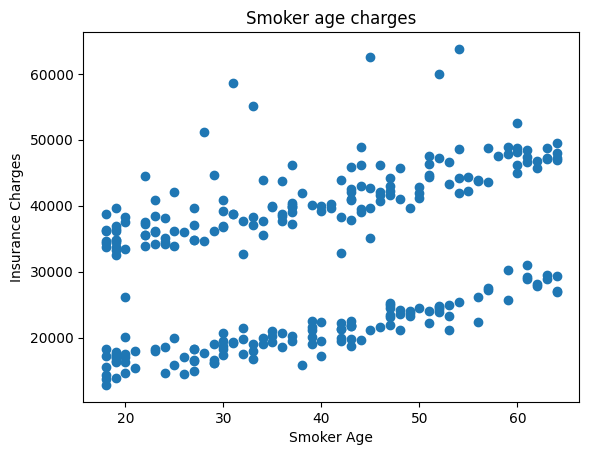

In [10]:
x = smokedata['age']
y = smokedata['charges']

plt.scatter(x, y)
plt.title('Smoker age charges')
plt.xlabel("Smoker Age")
plt.ylabel("Insurance Charges")

# Which region has the highest charges?

In [18]:

regionalcharge = dt.drop(['age','sex','bmi','children','smoker'],axis = 1)

In [31]:
dt.groupby('region')['charges'].mean().idxmax()

'southeast'

# What factors affect charges?

In [32]:
dt.groupby('smoker')['charges'].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

In [33]:
dt.groupby('region')['charges'].mean()

region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

## Smoking status appears to be the strongest factor associated with insurance charges. Smokers have substantially higher average charges than non-smokers. Age also appears to be associated with higher charges, particularly among smokers, while region shows smaller differences in average charges.